In [62]:
##Importing packages
import requests ##used to send HTTP requests to the government APIs
import pandas as pd #used for data manipulation and creating the final CSV
import numpy as np ## used for math operations and handling numeric data
import matplotlib.pyplot as plt ## used for creating containers and managing graph layouts
import seaborn as sns ## used for visualizations and styling the data plots

In [74]:
##CENSUS CODES (Resource 1)
income_code = "B19013_001E"  ### save the code for the "Median Household Income" Census variable in a string
pop_code = "B01003_001E"     ## save the code for the "Total Population" Census variable in a string 

##list for bachelors(022), masters(023), professional (024), doctorate(025) attainment
education_code = ["B15003_022E", "B15003_023E", "B15003_024E", "B15003_025E"] 

RPP_all = "1" ##'1' represents the 'All Items' Regional Price Parity index (Resource 2)

## get API keys by following instructions under the Developer section. Filled in my info to receive a key. 
BEA_KEY = "8F024E50-295D-456C-8EF1-C7695242F328"
CENSUS_KEY = "f36641aa3e79a6f5ed7f6b0cc6c6d62acca9279d"

## GETTING BEA REGIONAL PRICES

## use f-string to add the BEA_KEY and the RPP_all variable to the API request URL.
## this request is for the 'MARPP' table for 2021 and 'GeoFips=MSA' to pull all metro areas at once (Resoruce 2)
bea_url = f"https://apps.bea.gov/api/data/?UserID={BEA_KEY}&method=GetData&datasetname=Regional&
        TableName=MARPP&LineCode={RPP_all}&Year=2021&GeoFips=MSA&ResultFormat=json"

## send the GET request to the BEA server, and then convert the raw response to JSON format
bea_response = requests.get(bea_url).json()

## loop through the nested dictionary structure (BEAAPI->Results->Data) to get the actual data row
## This specific path is where the govt stores the records for each metropolitan area
bea_results = bea_response['BEAAPI']['Results']['Data']

##GETTING CENSUS DATA

## Use the join function to convert the list of education codes into a comma-separated string for the URL
edu_query_str = ",".join(education_code)

## use f-string to add the CENSUS_KEY and the various Census codes to the API request URL
## This request is for the 2021 ACS 5-year survey and pulls data for every metropolitan area at once (Resource 1)
census_url = f"https://api.census.gov/data/2021/acs/acs5?get=NAME,{pop_code},{income_code},{edu_query_str}&
for=metropolitan%20statistical%20area/micropolitan%20statistical%20area:*&key={CENSUS_KEY}"

## send the GET request to the Census server, and then turn the raw response to JSON format
census_raw = requests.get(census_url).json()





In [75]:
##TESTING THE CODE
## BEA verification

## check the data type of bea_results to ensure it is a list of dictionaries
print(f"BEA data type: {type(bea_results)}")

## print the total number of records retrieved from the BEA
print(f"Total BEA metropolitan areas: {len(bea_results)}")

## inspect the first 3 items in the list to verify the 'GeoName' and 'DataValue' keys
print("First 3 BEA results for checking:")
print(bea_results[:3])


##CENSUS verification

## check the data type of census_raw
print(f"\nCensus data type: {type(census_raw)}")

## print the total number of records retrieved from the Census
print(f"Total Census records: {len(census_raw)}")

## inspect the first 3 Census results
print("First 3 Census results (Header + Data):")
print(census_raw[:3])


##PREVIEW
## create a temporary dataframe to see the BEA price data in a table format
print("BEA Data Preview:")
print(pd.DataFrame(bea_results).head())

## create a temporary dataframe to see the Census pay data in a table format
## we skip the first row [1:] because it contains the header labels
print("Census Data Preview:")
print(pd.DataFrame(census_raw[1:], columns=census_raw[0]).head())

BEA data type: <class 'list'>
Total BEA metropolitan areas: 387
First 3 BEA results for inspection:
[{'Code': 'MARPP-1', 'GeoFips': '10180', 'GeoName': 'Abilene, TX (Metropolitan Statistical Area)', 'TimePeriod': '2021', 'CL_UNIT': 'Index', 'UNIT_MULT': '0', 'DataValue': '91.675'}, {'Code': 'MARPP-1', 'GeoFips': '10420', 'GeoName': 'Akron, OH (Metropolitan Statistical Area)', 'TimePeriod': '2021', 'CL_UNIT': 'Index', 'UNIT_MULT': '0', 'DataValue': '93.528'}, {'Code': 'MARPP-1', 'GeoFips': '10500', 'GeoName': 'Albany, GA (Metropolitan Statistical Area)', 'TimePeriod': '2021', 'CL_UNIT': 'Index', 'UNIT_MULT': '0', 'DataValue': '89.320'}]

Census data type: <class 'list'>
Total Census records: 940
First 3 Census results (Header + Data):
[['NAME', 'B01003_001E', 'B19013_001E', 'B15003_022E', 'B15003_023E', 'B15003_024E', 'B15003_025E', 'metropolitan statistical area/micropolitan statistical area'], ['Aberdeen, SD Micro Area', '42476', '64194', '6428', '1569', '517', '361', '10100'], ['Aber

In [76]:
##CLEANING BEA PRICE DATA

## convert the results into a pandas dataframe for cleaning
df_prices = pd.DataFrame(bea_results)

##creating a new column to connect the cities from the datasets
##divides the state suffix before the opening parentheses, and selects the city only 
df_prices['City_Match'] = df_prices['GeoName'].str.split(' (', regex=False).str[0].str.strip()

##resource citation #4
##renaming cloumn for clarity 
df_prices = df_prices.rename(columns={'DataValue': 'Cost_Of_Living_RPP'})

##ensure the RPP values are numeric so math can be done (Resource 2)
df_prices['Cost_Of_Living_RPP'] = pd.to_numeric(df_prices['Cost_Of_Living_RPP'])

## keep only the columns needed for merging and analysis
## this prevents the NoteRef column with expected missing values from incorrectly dropping valid rows
df_prices = df_prices[['GeoFips', 'City_Match', 'Cost_Of_Living_RPP']]


## CLEANING CENSUS PAY AND EDUCATION (SKILLS) DATA

## create an empty list to store the processed Census records
census_list = []

## loop through the Census results starting at index 1 to skip the header row
for row in census_raw[1:]:
    ## sum the 4 education columns into a total 'High Skill' count
    ## use a list comprehension to convert strings to floats before adding up. 
    high_skill_sum = sum([float(i) for i in row[3:7] if i is not None]) 
    
    ## strip away " Metro Area" or " Micro Area" suffixes from the city name
    ## this is to make sure the names are an exact match to the BEA format for a successful merge
    city_label = row[0].split(" Metro")[0].split(" Micro")[0].strip()

    ## add the results for these cities as a dictionary to our list
    census_list.append({
        "GeoFips": row[-1],                ## GeoFips (row[-1]) is the official MSA ID shared by both the BEA and Census APIs
        "City_Label": city_label,       ## census-side name kept separately to avoid column conflict at merge
        "Population": float(row[1]) if row[1] else 0,          ##population count converted to float, 0 if data is missing
        "Median_Household_Income": float(row[2]) if row[2] else 0,       ##income value converted to float, 0 if data is missing
        "High_Skill_Total": high_skill_sum  ## total count of residents with bachelors, masters, professional, or doctorate degrees
    })

## turn the organized list of dictionaries into a pandas dataframe
df_census = pd.DataFrame(census_list)



In [77]:

##MERGING AND CREATING VARIABLES

## merge the price and pay dataframes on the shared government FIPS code
## merging on 'GeoFips' is reliable because it uses the official MSA ID
final_df = pd.merge(df_prices, df_census, on="GeoFips")

## .dropna() now targets the four columns required for the calculations
## prevents columns with expected missing values from incorrectly dropping valid rows (Resource 1)
final_df = final_df.dropna(subset=['Median_Household_Income', 'Cost_Of_Living_RPP', 'Population', 'High_Skill_Total'])


## CALCULATED VARIABLE 1: Real Purchasing Power (Real Wage)
## formula: Nominal Income / (RPP / 100). This represents the actual value of the salary.
final_df['Real_Purchasing_Power'] = (final_df['Median_Household_Income'] / (final_df['Cost_Of_Living_RPP'] / 100)).round(2)

## CALCULATED VARIABLE 2: Education Rate (Human Capital Density)
## formula: High Skill Total / Population. This creates our skill-level control variable.
final_df['Education_Rate'] = (final_df['High_Skill_Total'] / final_df['Population']).round(4)


## export the final cleaned dataset to a CSV file for the R regression analysis
final_df.to_csv('US_metro_purchasing_power.csv', index=False)

## display the first 5 rows of the finished master dataset
final_df.head()


,GeoFips,City_Match,Cost_Of_Living_RPP,City_Label,Population,Median_Household_Income,High_Skill_Total,Real_Purchasing_Power,Education_Rate
0,10180,"Abilene, TX",91.675,"Abilene, TX",175241.0,57356.0,28121.0,62564.49,0.1605
1,10420,"Akron, OH",93.528,"Akron, OH",702464.0,63331.0,161394.0,67713.41,0.2298
2,10500,"Albany, GA",89.320,"Albany, GA",149298.0,49500.0,21455.0,55418.72,0.1437
3,10540,"Albany, OR",101.934,"Albany-Lebanon, OR",127200.0,63313.0,17529.0,62111.76,0.1378
4,10580,"Albany-Schenectady-Troy, NY",98.995,"Albany-Schenectady-Troy, NY",898265.0,77758.0,246239.0,78547.40,0.2741


In [78]:
##TESTING CODE 

##MERGE VERIFICATION

## check total cities merged
print(f"Total cities merged: {len(final_df)}")

## check what percentage of the original BEA sample was retained
print(f"Percentage of BEA sample retained: {(len(final_df) / len(df_prices) * 100):.2f}%")


##COLUMN VERIFICATION

## confirm all expected columns are present before the graph section runs
expected_columns = ['GeoFips', 'City_Match', 'Cost_Of_Living_RPP',
                    'Median_Household_Income', 'Population',
                    'High_Skill_Total', 'Real_Purchasing_Power', 'Education_Rate']

missing = [col for col in expected_columns if col not in final_df.columns]

## print confirmation or flag any column the graph code will look for but cannot find
if missing:
    print(f"missing columns: {missing}")
else:
    print("All expected columns present")


##NULL VALUE VERIFICATION

## check for any null values in our calculated variables to ensure no missing math
print("Missing values per column:")
print(final_df[expected_columns].isnull().sum())


##MATH VERIFICATION

## check the Real Purchasing Power formula on a known city
## a city with RPP above 100 should have Real Purchasing Power less than its nominal income
## a city with RPP below 100 should have Real Purchasing Power more than its nominal income
sample = final_df[['City_Match', 'Cost_Of_Living_RPP','Median_Household_Income', 'Real_Purchasing_Power']].head(3)

print("Real Purchasing Power should be lower than Nominal in high-cost cities:")
print(sample)


##RANGE VERIFICATION

## confirm the economic variables are within realistic bounds before graphing
## RPP should sit between roughly 80–130, income between $40k–$150k
print("Economic stats:")
print(final_df[['Cost_Of_Living_RPP', 'Median_Household_Income','Real_Purchasing_Power', 'Education_Rate']].describe().round(2))



Total cities merged: 379
Percentage of BEA sample retained: 97.93%
All expected columns present
Missing values per column:
GeoFips                    0
City_Match                 0
Cost_Of_Living_RPP         0
Median_Household_Income    0
Population                 0
High_Skill_Total           0
Real_Purchasing_Power      0
Education_Rate             0
dtype: int64
Real Purchasing Power should be lower than Nominal in high-cost cities:
    City_Match  Cost_Of_Living_RPP  Median_Household_Income  \
0  Abilene, TX              91.675                  57356.0   
1    Akron, OH              93.528                  63331.0   
2   Albany, GA              89.320                  49500.0   

   Real_Purchasing_Power  
0               62564.49  
1               67713.41  
2               55418.72  
Economic stats:
       Cost_Of_Living_RPP  Median_Household_Income  Real_Purchasing_Power  \
count              379.00                   379.00                 379.00   
mean                94.64    

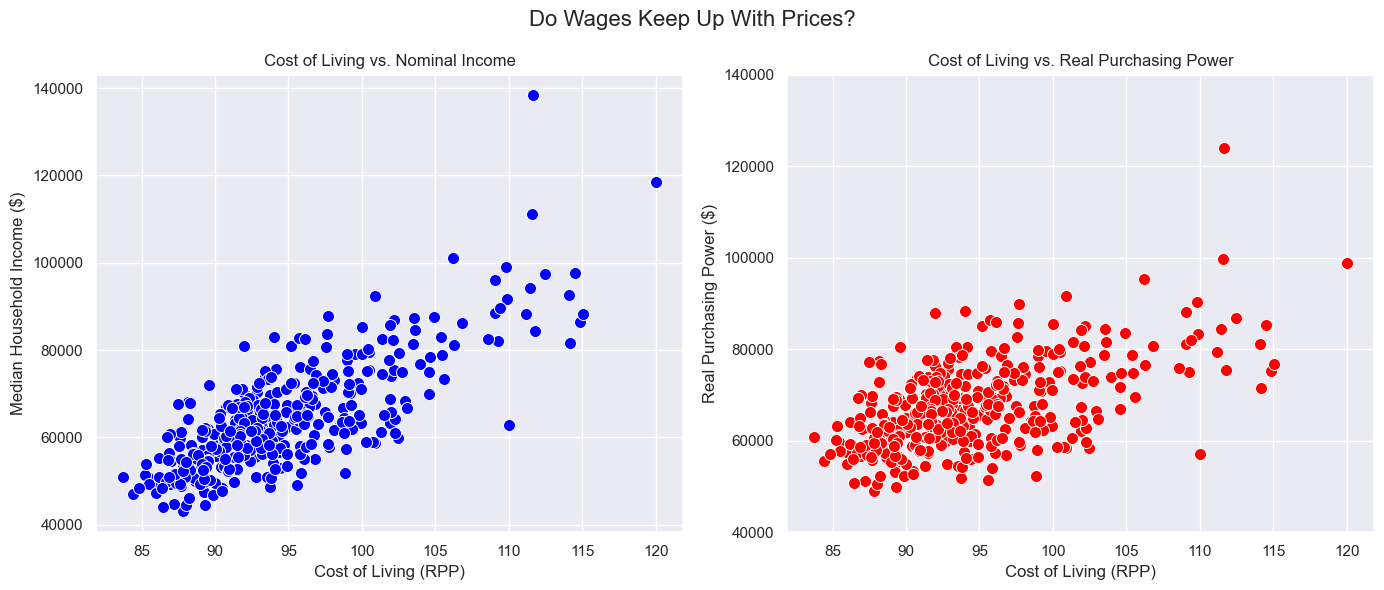

In [79]:
sns.set_style("whitegrid")
sns.set(font_scale=1)

fig = plt.figure(figsize=(14, 6))##creates an empty container with the listed size

##GRAPH 1--> Nominal Income (LEFT)

## creates the first subplot space in the container (1 row and 2 columns)
ax1 = plt.subplot(1, 2, 1)

##creates a scatter plot for the first graph using our dataset, setting the dots to blue and making them 75 in size
sns.scatterplot(x='Cost_Of_Living_RPP', y='Median_Household_Income', data=final_df, ax=ax1, color='blue', s=75)

ax1.set_title('Cost of Living vs. Nominal Income') ##adds title for graph on left
## establish the labels
ax1.set_xlabel('Cost of Living (RPP)')
ax1.set_ylabel('Median Household Income ($)')

## forces the y-axis to use these tick marks so both graphs share the same scale
ax1.set_yticks([40000, 60000, 80000, 100000, 120000, 140000])



## GRAPH 2--> Real Purchasing Power (RIGHT)


## creates the second subplot space in our container
ax2 = plt.subplot(1, 2, 2)

##creates the second scatter plot for real purchasing power, putting it in the ax2 space and coloring the dots red
sns.scatterplot(x='Cost_Of_Living_RPP', y='Real_Purchasing_Power', data=final_df, ax=ax2, color='red', s=75) 

ax2.set_title('Cost of Living vs. Real Purchasing Power') ##adds title for graph on right
## establish the labels 
ax2.set_xlabel('Cost of Living (RPP)')
ax2.set_ylabel('Real Purchasing Power ($)')

## forces the y-axis to use these tick marks so both graphs share the same scale
ax2.set_yticks([40000, 60000, 80000, 100000, 120000, 140000])

##adds a title over the entire container
fig.suptitle('Do Wages Keep Up With Prices?', fontsize=16) 

## automatically adjust params so nothing overlaps
fig.tight_layout()

## save the figure as a high-resolution PNG for professional use (Resource 2)
plt.savefig('Nominal_vs_Real_Wealth.png', dpi=300, bbox_inches='tight')

plt.show()

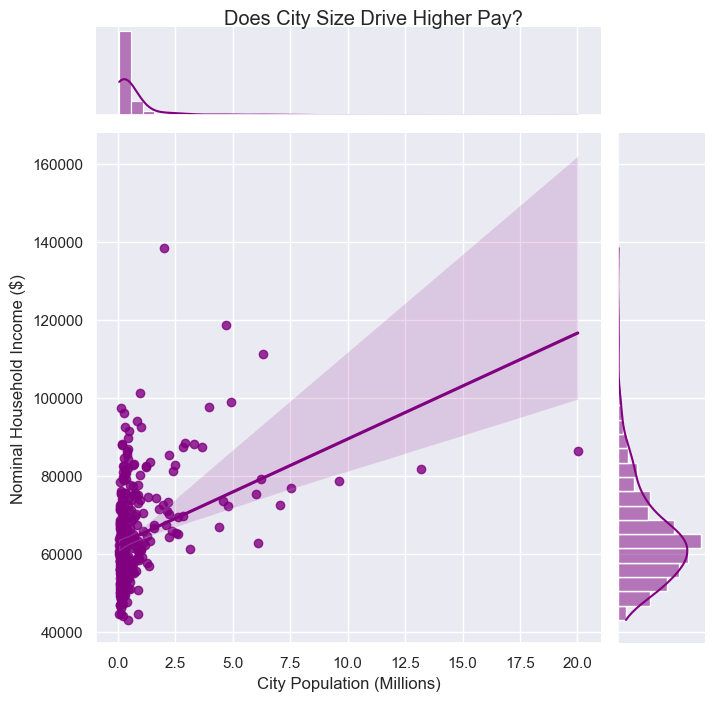

In [80]:
##GRAPH 3--> Big City Premium (Population vs. Nominal Income)

## divide population for cleaner labels
final_df['Pop_Millions'] = final_df['Population'] / 1000000

## generate a jointplot to visualize distributions and the regression line
## we use kind='reg' to include the linear trend and purple for visual distinction (Resource 1)
jp1 = sns.jointplot(x='Pop_Millions', y='Median_Household_Income', data=final_df, kind='reg', color='purple', height=7)

## establish the labels for the joint plot axes
jp1.set_axis_labels('City Population (Millions)', 'Nominal Household Income ($)')

## apply a title and use y=1.0 to ensure it is positioned at the top of the histograms 
jp1.fig.suptitle('Does City Size Drive Higher Pay?', y=1.0)

## save the jointplot (Resource 2)
plt.savefig('Population_vs_Income.png', dpi=300, bbox_inches='tight')

plt.show()

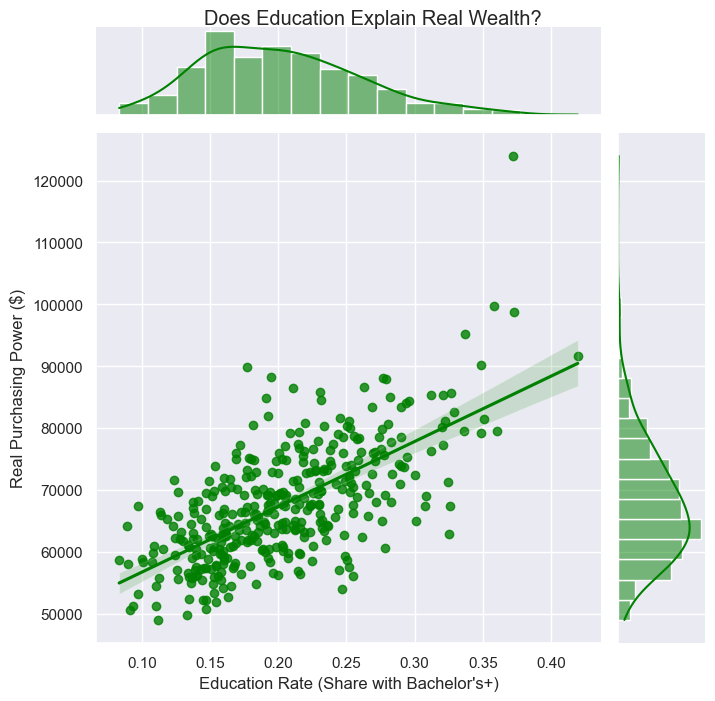

In [81]:
##GRAPH 4--> Big City Education (Education Rate vs. Real Purchasing Power)

## generate a jointplot comparing education rates to real purchasing power
## we use kind='reg' to include the linear trend and green for visual distinction
jp2 = sns.jointplot(x='Education_Rate', y='Real_Purchasing_Power', data=final_df, kind='reg', color='green', height=7)

## establish labels describing the share of residents with a bachelor's degree or higher
jp2.set_axis_labels('Education Rate (Share with Bachelor\'s+)', 'Real Purchasing Power ($)')

## apply a title and use y=1.0 to ensure it is positioned at the top of the histograms 
jp2.fig.suptitle('Does Education Explain Real Wealth?', y=1.0)

## save the jointplot (Resource 2)
plt.savefig('Education_vs_Real_Wealth.png', dpi=300, bbox_inches='tight')

plt.show() 

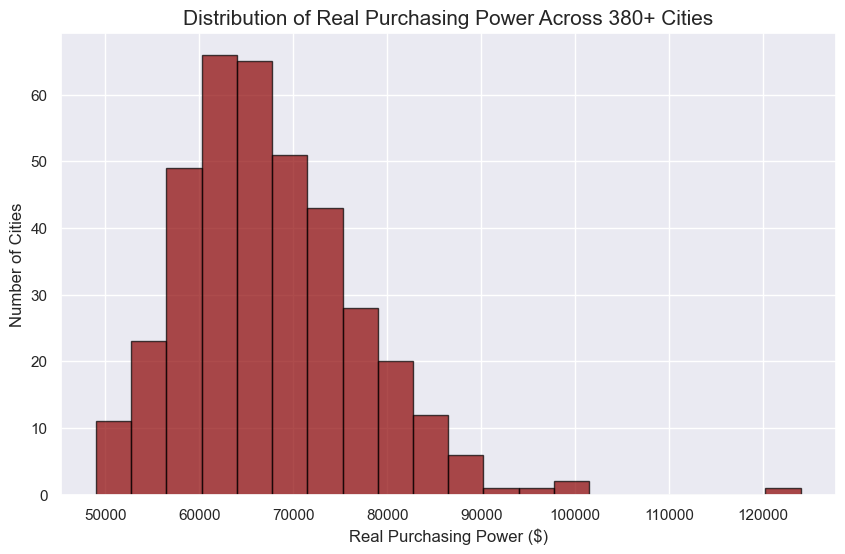

In [82]:
##GRAPH 5--> Real Purchasing Power Distribution

## set the figure size for the presentation slide
plt.figure(figsize=(10, 6))

## create a histogram of Real Purchasing Power
## bins=20 divides the data into 20 groups
plt.hist(final_df['Real_Purchasing_Power'], bins=20, color='darkred', ec='black', alpha=0.7)

## add labels and title
plt.title('Distribution of Real Purchasing Power Across 380+ Cities', fontsize=15)
plt.xlabel('Real Purchasing Power ($)', fontsize=12)
plt.ylabel('Number of Cities', fontsize=12)

## save the graph for the presentation (Resource 2)
plt.savefig('Wealth_Distribution.png', dpi=300, bbox_inches='tight')

plt.show()